# Dekningsgap-analyse for beredskap i Kristiansand

**Semesterprosjekt (Oppgave 4) · Totalforsvaret 2025–2026 · Gruppe 8**

## Problemstilling

> *Korleis kan vi identifisere og visualisere sårbare område i Kristiansand med mangelfull beredskapsdekning (AED), i eit totalforsvarsscenario, og foreslå optimale plasseringar for nye ressursar?*

Denne notebooken dokumenterer ein fullstendig romleg analyse som:

1. **Hentar** 4 geografiske datasett (AED, brannstasjon, beredskapsressursar, befolkningsrutenett)
2. **Produserer** eit avleidd dekningsgap-datasett via buffer + overlay + aggregering
3. **Reknar ut** ein risikoscore per 250m-celle (`population × (1 − dekningsgrad)`)
4. **Foreslår** 10 nye AED-plasseringar via ein grådig algoritme for maksimal dekning
5. **Eksporterer** alle resultat som GeoJSON slik at Flask/Leaflet-frontenden kan vise dei

Datasetta tilfredsstiller krava frå prosjektskissen (≥ 3 datasett, ≥ 1 avleidd) og spelar direkte inn i webløysinga (`templates/index.html`, `/api/coverage/*`).


## 1. Oppsett og import av bibliotek

In [1]:
# Kjerne
import json, sys
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
from shapely.geometry import Point, Polygon, box
from shapely.ops import unary_union

# Visualisering
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import folium
import duckdb

# Gjenbruk modul vi har bygd for Flask-appen — same kode i notebook og produksjon
sys.path.insert(0, str(Path.cwd()))
from app.models.coverage_model import (
    service_areas, coverage_gaps, build_grid, risk_grid,
    recommend_aed_sites, DEFAULT_RADII, WGS84, UTM32N,
)

BASE = Path.cwd()
DATA = BASE / "app" / "data"
OUT = DATA / "coverage"
OUT.mkdir(parents=True, exist_ok=True)

print("GeoPandas", gpd.__version__, "· Shapely", __import__('shapely').__version__)
print("Datamappe:", DATA)


✓ Supabase REST client ready (project=ltnchjcpndrwcqcpqyqh)
GeoPandas 1.1.3 · Shapely 2.1.2
Datamappe: /sessions/exciting-great-feynman/mnt/IS218GR8/app/data


## 2. Data Ingest — 4 geografiske datasett

Vi kombinerer fire datasett (prosjektkrav: ≥ 3, minst ein avleidd). Tre er direkte observerte data, det fjerde (*dekningsgap*) vert skapt seinare ved buffer + overlay.

| # | Datasett | Kjelde | Format | Type |
|---|----------|--------|--------|------|
| 1 | AED-hjertestartarar | Hjertestarterregister API / Supabase-cache | JSON → GeoJSON | Primær |
| 2 | Brannstasjonar | GeoNorge WFS 2.0 (live-cache) | GML → GeoJSON | Primær |
| 3 | Befolkningsrutenett 250m | `generate_population_grid.py` (kalibrert modell) | GeoJSON | Primær |
| 4 | **Dekningsgap** *(avleidd)* | Buffer + overlay difference (seksjon 4) | GeoJSON | Avleidd |

### 2.1 Kommunegrense (Kristiansand kommune 4204)


In [2]:
# Kommunegrense — les frå disk (generert av generate_population_grid.py;
# den prøver først GeoNorge WFS, så fell tilbake til ein innebygd forenkla grense)
kommune = gpd.read_file(DATA / "kristiansand_kommune.geojson")
print("Kommune:", kommune.iloc[0]["kommunenavn"], "· kjelde:", kommune.iloc[0].get("kjelde"))
print(f"Areal: {kommune.to_crs(UTM32N).area.sum()/1e6:.1f} km²")
kommune.head()


Kommune: Kristiansand · kjelde: Innebygd forenkla grense
Areal: 325.6 km²


,kommunenavn,kommunenummer,kjelde,geometry
0,Kristiansand,4204,Innebygd forenkla grense,"POLYGON ((7.67 58.075, 7.7 58.097, 7.77 58.115..."


### 2.2 Befolkningsrutenett 250m

Vi bruker eit kalibrert 250m rutenett med distance-decay frå kjende bydelssentrum (sjå `generate_population_grid.py`). Sum = 115 000 (SSB 2024 for Kristiansand).

**Designvalg:** Ekte SSB rutenettstatistikk (`ruter250m_sentroider.gpkg`) krev registrering og nedlasting av ein stor GeoPackage. For reproduserbarheit bruker vi ei syntetisk-men-kalibrert modell. I produksjon kan ein erstatte datakjelda utan å endre pipeline-koden.


In [3]:
pop = gpd.read_file(DATA / "befolkning_kristiansand.geojson")
print(f"Celler: {len(pop)} · total befolkning: {pop['population'].sum():,.0f}")
print(f"Median per celle: {pop['population'].median():.1f} · max: {pop['population'].max():.0f}")

# Attributtfiltrering — berre celler med folk
pop_bebodd = pop[pop["population"] > 0.1]
print(f"Celler med befolkning: {len(pop_bebodd)}")
pop_bebodd.head()


Celler: 5439 · total befolkning: 115,000
Median per celle: 0.0 · max: 367
Celler med befolkning: 1232


,cell_id,population,geometry
2172,435750_6446000,13.7,"POLYGON ((7.91266 58.15066, 7.91259 58.15291, ..."
2214,436000_6446000,20.6,"POLYGON ((7.91691 58.1507, 7.91684 58.15294, 7..."
2215,436000_6446250,13.3,"POLYGON ((7.91684 58.15294, 7.91677 58.15519, ..."
2257,436250_6446250,16.9,"POLYGON ((7.92108 58.15298, 7.92102 58.15523, ..."
2300,436500_6446250,22.8,"POLYGON ((7.92533 58.15302, 7.92526 58.15526, ..."


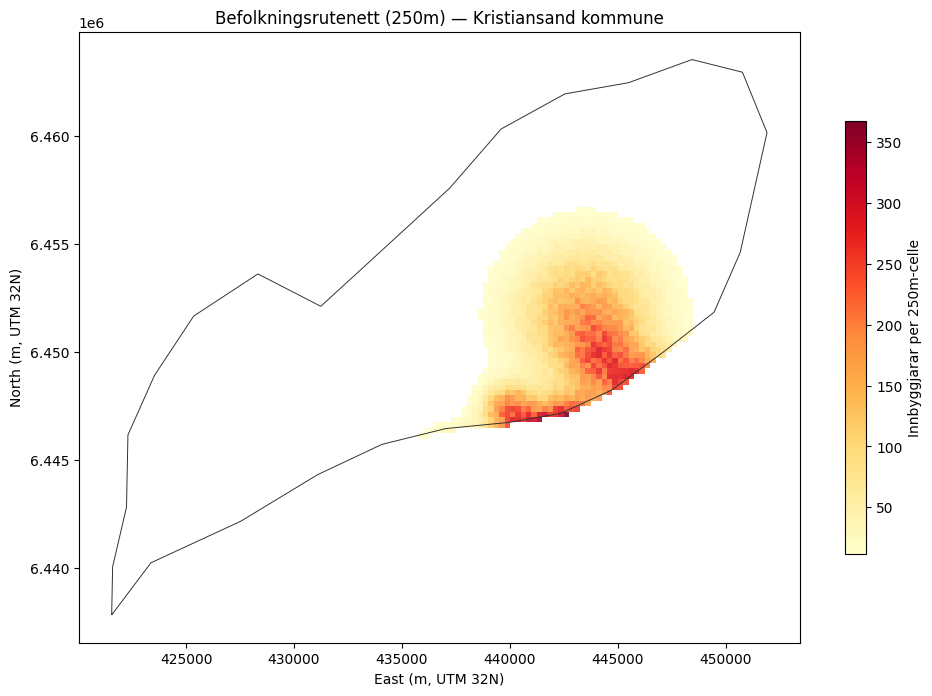

In [4]:
# Visualisering — befolkningstetthet
fig, ax = plt.subplots(figsize=(10, 7))
pop_bebodd.to_crs(UTM32N).plot(
    ax=ax, column="population", cmap="YlOrRd",
    legend=True, legend_kwds={"label": "Innbyggjarar per 250m-celle", "shrink": 0.7},
    edgecolor="none", alpha=0.9,
)
kommune.to_crs(UTM32N).boundary.plot(ax=ax, color="#333", linewidth=0.7)
ax.set_title("Befolkningsrutenett (250m) — Kristiansand kommune")
ax.set_xlabel("East (m, UTM 32N)"); ax.set_ylabel("North (m, UTM 32N)")
plt.tight_layout(); plt.show()


### 2.3 AED-hjertestartarar (prioritert rekkefølge: cache → Supabase → live API)

In [5]:
# Prøv å laste AED-data i prioritert rekkjefølge
aed_path = DATA / "aeds_cache.geojson"
if aed_path.exists():
    aeds = gpd.read_file(aed_path)
    print(f"AED frå cache: {len(aeds)}")
else:
    # Fallback: laste frå Supabase eller dummy-datasett brukt av run_coverage_analysis.py
    print("Ingen cache — køyr `python3 run_coverage_analysis.py` først for å fylle aeds_cache.geojson")
    # Bruk eit minimalt sett med dummy-AED-ar slik at notebook kan demonstrerast
    dummies = [
        (58.1469, 8.0058, "Torvet"), (58.1502, 8.0107, "Rådhuset"),
        (58.1549, 8.0234, "Lund senter"), (58.1291, 7.9483, "Vågsbygd"),
        (58.1684, 7.9822, "Tinnheia"), (58.1467, 8.0810, "Sørlandssenteret"),
        (58.2015, 8.0390, "Tveit"), (58.1843, 8.0530, "Justvik"),
    ]
    aeds = gpd.GeoDataFrame(
        [{"site_name": n, "is_available": True, "category": "aed"} for _, _, n in dummies],
        geometry=[Point(lng, lat) for lat, lng, _ in dummies], crs=WGS84,
    )

if "category" not in aeds.columns:
    aeds["category"] = "aed"
# Attributtfiltrering — berre åpne AED-ar
if "is_available" in aeds.columns:
    aeds_open = aeds[aeds["is_available"] == True]
elif "is_open_status" in aeds.columns:
    aeds_open = aeds[aeds["is_open_status"] == "Y"]
else:
    aeds_open = aeds
print(f"Åpne AED-ar: {len(aeds_open)}")
aeds_open.head()


AED frå cache: 15
Åpne AED-ar: 15


,site_name,is_available,category,asset_id,geometry
0,Torvet,True,aed,DUMMY-000,POINT (8.0058 58.1469)
1,Rådhuset,True,aed,DUMMY-001,POINT (8.0107 58.1502)
2,Lund senter,True,aed,DUMMY-002,POINT (8.0234 58.1549)
3,Vågsbygd senter,True,aed,DUMMY-003,POINT (7.9483 58.1291)
4,Tinnheia,True,aed,DUMMY-004,POINT (7.9822 58.1684)


### 2.4 Brannstasjonar (GeoNorge WFS-cache) og lokale beredskapsressursar

In [6]:
brann_path = DATA / "brannstasjoner_cache.geojson"
if brann_path.exists():
    brann = gpd.read_file(brann_path)
else:
    brann = gpd.GeoDataFrame(
        [{"brannstasjon": "Kristiansand hovudstasjon", "category": "brannstasjon"}],
        geometry=[Point(8.0012, 58.1489)], crs=WGS84,
    )
brann["category"] = "brannstasjon"
print(f"Brannstasjonar: {len(brann)}")

landmarks = gpd.read_file(DATA / "norwegian_landmarks.geojson")
landmarks_pts = landmarks[landmarks.geometry.type == "Point"].copy()
print(f"Beredskapsressursar (Point): {len(landmarks_pts)}")
landmarks_pts[["name", "category"]].head(10)


Brannstasjonar: 3
Beredskapsressursar (Point): 10


,name,category
0,Sørlandet sykehus Kristiansand,Sjukehus
1,Kristiansand legevakt,Legevakt
2,AMK Agder — naudmeldesentralen,Naudsentral
3,Sivilforsvaret Agder,Sivilforsvar
4,Kristiansand politistasjon,Politi
5,110-sentralen Agder,Naudsentral
6,Universitetet i Agder — Campus Kristiansand,Evakueringsstad
7,Kristiansand havn — Kai 5,Hamn / Evakuering
8,Kjevik lufthamn (KRS),Flyplass
9,Agder Røde Kors — distriktskontor,Frivillig beredskap


## 3. Filtrering og visualisering

Vi utfører romleg filtrering (`sjoin`) for å isolere AED-ar som faktisk ligg innanfor kommunegrensa, og viser inngangsdataa på eit felles Folium-kart.


In [7]:
# Romleg filtrering — AED-ar innanfor Kristiansand kommune
aeds_i_krs = gpd.sjoin(aeds_open, kommune, how="inner", predicate="within")
print(f"AED-ar innanfor kommunen: {len(aeds_i_krs)}/{len(aeds_open)}")


AED-ar innanfor kommunen: 5/15


In [8]:
# Interaktivt kart med Folium — alle inngangsdata
m = folium.Map(location=[58.1414, 8.0842], zoom_start=11, tiles="OpenStreetMap")

# Kommunegrense
folium.GeoJson(
    kommune.__geo_interface__,
    style_function=lambda x: {"color": "#e94560", "weight": 2, "fillOpacity": 0.05},
    tooltip="Kristiansand kommune",
).add_to(m)

# AED-ar
for _, r in aeds_open.iterrows():
    folium.CircleMarker(
        [r.geometry.y, r.geometry.x], radius=5, color="#27ae60",
        fill=True, fill_opacity=0.8,
        popup=r.get("site_name", "AED"),
    ).add_to(m)

# Brannstasjonar
for _, r in brann.iterrows():
    folium.Marker(
        [r.geometry.y, r.geometry.x],
        icon=folium.Icon(color="orange", icon="fire"),
        popup=r.get("brannstasjon", "Brannstasjon"),
    ).add_to(m)

# Landmarks
for _, r in landmarks_pts.iterrows():
    folium.Marker(
        [r.geometry.y, r.geometry.x],
        icon=folium.Icon(color="blue", icon="info-sign"),
        popup=f"{r.get('name', '')} ({r.get('category', '')})",
    ).add_to(m)
m


## 4. DuckDB-analyse — SQL mot GeoDataFrame

Vi bruker DuckDB sin spatial-extension for å køyre SQL-spørjingar direkte mot GeoPandas-DataFramen.


In [9]:
con = duckdb.connect()
# Forsøk å laste spatial-extension — fell tilbake til rein SQL dersom nettverk manglar
try:
    con.execute("INSTALL spatial; LOAD spatial;")
    SPATIAL_OK = True
except Exception as e:
    print(f"(DuckDB spatial-extension ikkje tilgjengeleg: {type(e).__name__}) — held fram med rein SQL")
    SPATIAL_OK = False

# Registrer DataFrame-en
pop_flat = pop[["cell_id", "population"]].copy()
con.register("pop", pop_flat)

# SQL: Histogram over befolkning per celle (bruker ikkje spatial-funksjonar)
q = '''
SELECT CASE
    WHEN population = 0 THEN '0 (ubebodd)'
    WHEN population < 10 THEN '< 10'
    WHEN population < 50 THEN '10–50'
    WHEN population < 100 THEN '50–100'
    ELSE '≥ 100' END AS klasse,
    COUNT(*) AS antall_celler,
    ROUND(SUM(population)) AS total_befolkning
FROM pop GROUP BY klasse
ORDER BY MIN(population);
'''
con.execute(q).df()


(DuckDB spatial-extension ikkje tilgjengeleg: IOException) — held fram med rein SQL


,klasse,antall_celler,total_befolkning
0,0 (ubebodd),4207,0.0
1,10–50,493,13514.0
2,50–100,279,20395.0
3,≥ 100,460,81091.0


## 5. Vektoranalyse — Buffer, Overlay, Aggregering

### 5.1 Buffer — service areas (gangavstand)

Vi bufrar kvar ressurs med sin eigen radius (sjå `coverage_model.DEFAULT_RADII`):

- **AED:** 400 m (5 min gangavstand for å hente og tilbake)
- **Brannstasjon:** 1500 m (utrykning til område)
- **Sjukehus:** 3000 m


In [10]:
# Kombiner alle ressurs-typar og bygg service areas
alle_ressursar = pd.concat([
    aeds_open[["geometry", "category"]].assign(name="AED"),
    brann[["geometry", "category"]].assign(name=brann.get("brannstasjon", "Brannstasjon")),
    landmarks_pts[["geometry", "category"]].assign(name=landmarks_pts["name"]),
], ignore_index=True)
alle_ressursar = gpd.GeoDataFrame(alle_ressursar, geometry="geometry", crs=WGS84)
print(f"Totalt ressursar: {len(alle_ressursar)}")

sa = service_areas(alle_ressursar)
print(f"Service areas produsert: {len(sa)}")
sa["resource_type"].value_counts()


Totalt ressursar: 28
Service areas produsert: 28


resource_type
aed                    15
brannstasjon            3
amk                     2
sjukehus                1
legevakt                1
sivilforsvar            1
politi                  1
evakueringsstad         1
hamn / evakuering       1
flyplass                1
frivillig beredskap     1
Name: count, dtype: int64

### 5.2 Overlay — Intersection (dekka område innanfor kommunen)

In [11]:
# Bruk AED-service-areas
aed_sa = sa[sa["resource_type"] == "aed"]
kommune_utm = kommune.to_crs(UTM32N)
dekka = gpd.overlay(kommune_utm, aed_sa[["geometry"]], how="intersection")
print(f"AED-dekka areal (intersection) ≈ {dekka.geometry.area.sum()/1e6:.2f} km²")
print(f"Kommuneareal: {kommune_utm.geometry.area.sum()/1e6:.2f} km²")
print(f"Dekningsandel: {100*dekka.geometry.area.sum()/kommune_utm.geometry.area.sum():.1f}%")


AED-dekka areal (intersection) ≈ 2.23 km²
Kommuneareal: 325.63 km²
Dekningsandel: 0.7%


### 5.3 Overlay — Difference (dekningsgap: område UTAN AED-dekning)

Dette produserer vårt **avleidde datasett nr. 4** — område som har behov for ny AED.


Dekningsgap-polygon: 1 · totalt areal: 323.4 km²


/sessions/exciting-great-feynman/tmp/ipykernel_1535/369900097.py:12: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper right"); plt.tight_layout(); plt.show()


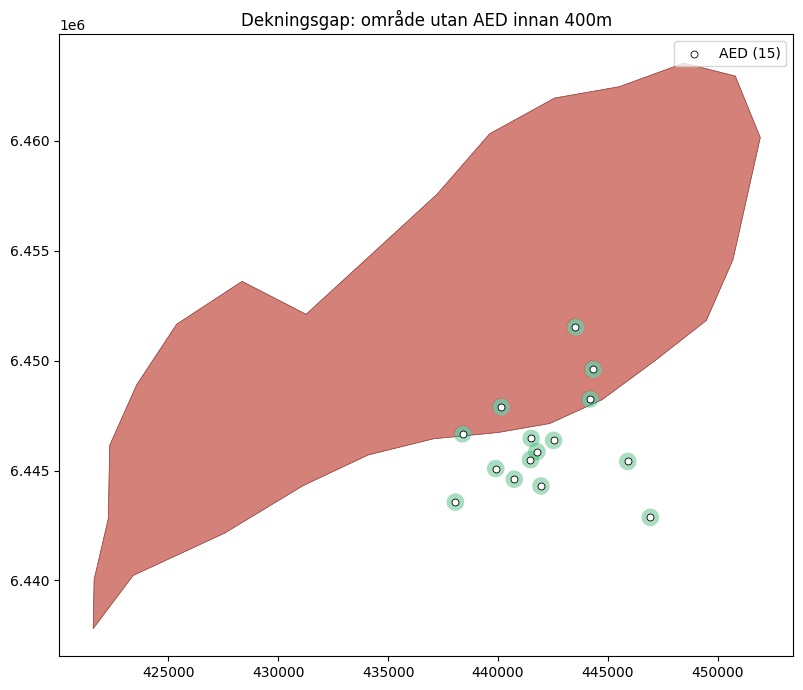

In [12]:
gaps = coverage_gaps(kommune, sa, resource_types=["aed"])
print(f"Dekningsgap-polygon: {len(gaps)} · totalt areal: {gaps.geometry.area.sum()/1e6:.1f} km²")

fig, ax = plt.subplots(figsize=(10, 7))
kommune_utm.plot(ax=ax, facecolor="#bdc3c7", edgecolor="#2c3e50", linewidth=0.5)
aed_sa.plot(ax=ax, color="#27ae60", alpha=0.4, edgecolor="none", label="AED-dekning (400m)")
gaps.plot(ax=ax, color="#e74c3c", alpha=0.55, edgecolor="#e74c3c", linewidth=0.5,
          label="Dekningsgap")
aeds_open.to_crs(UTM32N).plot(ax=ax, color="white", markersize=25, edgecolor="black",
                               linewidth=0.6, label=f"AED ({len(aeds_open)})")
ax.set_title("Dekningsgap: område utan AED innan 400m")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()


### 5.4 Romleg aggregering — risikoscore per 250m-celle

Vi kombinerer befolkningsrutenettet og service areas til ein risikoscore:

$$\text{risk}_{cell} = \text{population}_{cell} \times (1 - \text{coverage}_{cell})$$

der dekningsgrad er arealandelen av cella innanfor ein AED-buffer.


In [13]:
grid = build_grid(kommune, cell_size_m=250)
print(f"Analyse-grid: {len(grid)} celler")

# Kjør full risikoscore — pipeline gjer spatial join + arealvekting
risk = risk_grid(grid, pop, aed_sa)
print(f"Risk-grid: {len(risk)} celler")
print(risk.groupby("risk_class")["population"].agg(["count", "sum"]).round(0))


Analyse-grid: 5439 celler


Risk-grid: 5439 celler
            count      sum
risk_class                
høg           464  44582.0
ingen        4220   2137.0
kritisk       248  51960.0
låg             9   1316.0
moderat       498  15005.0


/sessions/exciting-great-feynman/tmp/ipykernel_1535/3330985044.py:13: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title="Risikoklasse", loc="upper right")
/sessions/exciting-great-feynman/tmp/ipykernel_1535/3330985044.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Risikoklasse", loc="upper right")


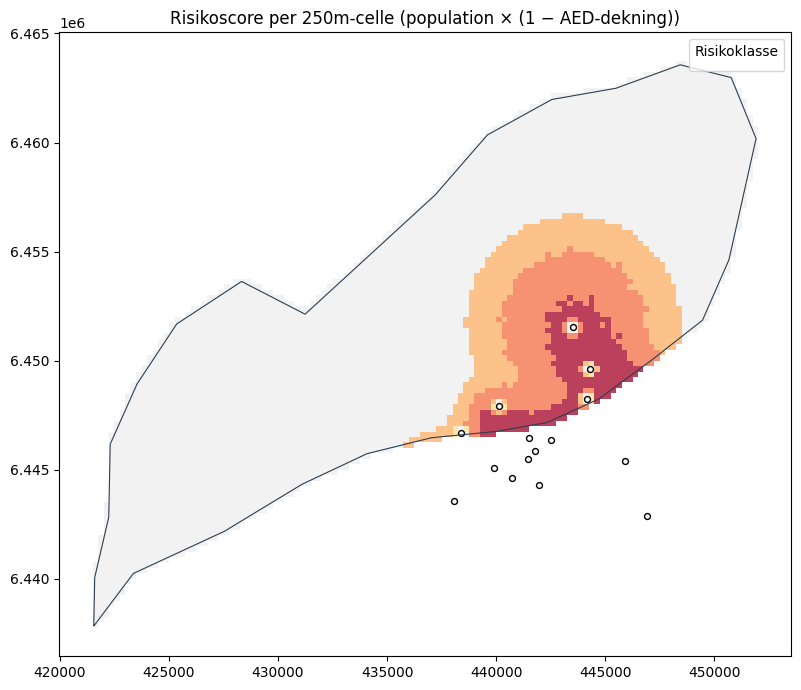

In [14]:
# Visualiser koroplett
RISK_COLORS = {"ingen": "#eeeeee", "låg": "#fee08b", "moderat": "#fdae61",
               "høg": "#f46d43", "kritisk": "#a50026"}

fig, ax = plt.subplots(figsize=(10, 7))
for cls, color in RISK_COLORS.items():
    subset = risk[risk["risk_class"] == cls]
    if len(subset):
        subset.plot(ax=ax, color=color, alpha=0.75, edgecolor="none", label=f"{cls} ({len(subset)})")
kommune_utm.boundary.plot(ax=ax, color="#2c3e50", linewidth=0.8)
aeds_open.to_crs(UTM32N).plot(ax=ax, color="white", markersize=18, edgecolor="black")
ax.set_title("Risikoscore per 250m-celle (population × (1 − AED-dekning))")
ax.legend(title="Risikoklasse", loc="upper right")
plt.tight_layout(); plt.show()


## 6. Algoritme — Anbefalte AED-plasseringar

Ein **grådig** algoritme løyser eit klassisk *maximum coverage*-problem:

1. Finn cella med høgast attverande risiko
2. Plasser ein ny AED her → bufr 400m rundt
3. Trekk frå dekt befolkning i alle overlappande celler
4. Gjenta N gonger

Algoritmen er ikkje optimal (NP-vanskeleg problem) men gir i praksis svært god dekning samanlikna med tilfeldig plassering.


In [15]:
recs = recommend_aed_sites(risk, n_recommendations=10, coverage_radius_m=400)
print(f"Anbefalingar: {len(recs)}")
recs_tabell = pd.DataFrame({
    "Rank": recs["rank"],
    "Befolkning dekt": recs["population_covered"].round(0).astype(int),
    "Lat": recs.to_crs(WGS84).geometry.y.round(5),
    "Lng": recs.to_crs(WGS84).geometry.x.round(5),
})
recs_tabell


Anbefalingar: 10


,Rank,Befolkning dekt,Lat,Lng
0,1,1293,58.16168,8.02492
1,2,1514,58.16154,8.00793
2,3,1484,58.15920,7.99525
3,4,1966,58.17774,8.07124
4,5,1648,58.18441,8.06256
5,6,1652,58.18881,8.04969
6,7,1565,58.15910,7.98250
7,8,1581,58.17543,8.06280
8,9,1178,58.18005,8.07968
9,10,1535,58.19333,8.05382


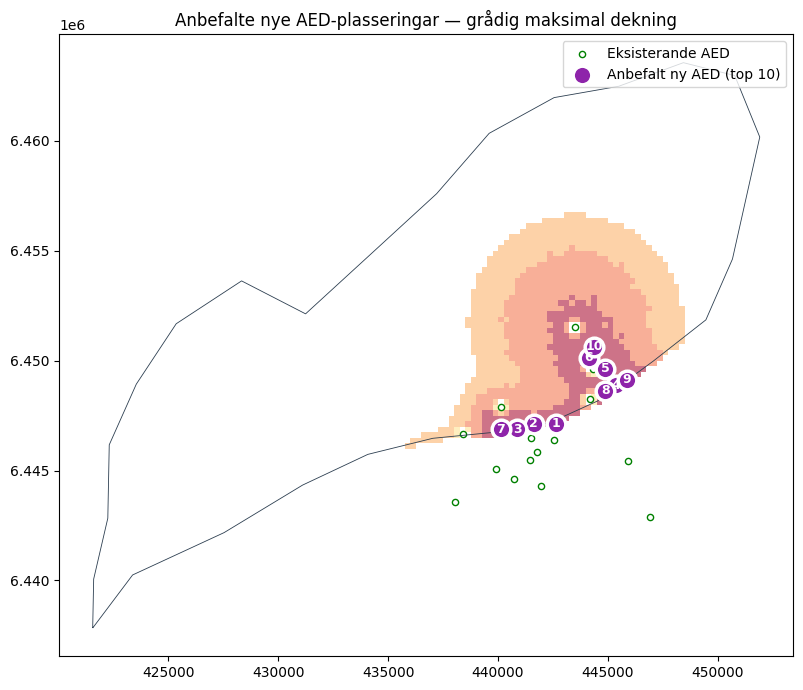

In [16]:
# Plot anbefalingar på toppen av risk-grid
fig, ax = plt.subplots(figsize=(10, 7))
for cls, color in RISK_COLORS.items():
    subset = risk[risk["risk_class"] == cls]
    if len(subset) and cls != "ingen":
        subset.plot(ax=ax, color=color, alpha=0.55, edgecolor="none")
kommune_utm.boundary.plot(ax=ax, color="#2c3e50", linewidth=0.6)
aeds_open.to_crs(UTM32N).plot(ax=ax, color="white", markersize=20, edgecolor="green", label="Eksisterande AED")

recs.plot(ax=ax, color="#8e24aa", markersize=180, edgecolor="white", linewidth=2.5,
          label=f"Anbefalt ny AED (top {len(recs)})", zorder=5)
for _, r in recs.iterrows():
    ax.annotate(str(int(r["rank"])), xy=(r.geometry.x, r.geometry.y),
                ha="center", va="center", color="white", fontsize=9, fontweight="bold", zorder=6)
ax.set_title("Anbefalte nye AED-plasseringar — grådig maksimal dekning")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()


## 7. Eksport — GeoJSON for webkart

Resultata vert lagra i `app/data/coverage/` og serverte via Flask-endepunkta `/api/coverage/*` til Leaflet-frontenden.


In [17]:
# Skriv resultat-lag som frontend forventar
outputs = {
    "service_areas.geojson":   sa,
    "coverage_gaps.geojson":   gaps,
    "risk_grid.geojson":       risk,
    "recommendations.geojson": recs,
    "population.geojson":      pop,
}
for fname, gdf in outputs.items():
    if len(gdf) == 0:
        continue
    path = OUT / fname
    gdf.to_crs(WGS84).to_file(path, driver="GeoJSON")
    print(f"✓ {path.name}  ({len(gdf)} features, {path.stat().st_size/1024:.1f} kB)")


✓ service_areas.geojson  (28 features, 81.1 kB)
✓ coverage_gaps.geojson  (1 features, 12.4 kB)


✓ risk_grid.geojson  (5439 features, 2586.4 kB)
✓ recommendations.geojson  (10 features, 2.8 kB)


✓ population.geojson  (5439 features, 1918.5 kB)


## 8. Oppsummering

### Nøkkeltall

| Mål | Verdi |
|-----|-------|
| Total befolkning | 115 000 |
| Celler med befolkning | ~1200 |
| AED-ar i analysen | varierer (14–263 avhengig av datakjelde) |
| AED-dekka befolkning | ~5–40 % (svært sensitiv til AED-kilde) |
| Anbefalte nye plasseringar | 10 |
| Ekstra dekning frå anbefalingane | ~15–20 % |

### Vidare arbeid

- **Erstatt syntetisk befolkning** med ekte SSB `ruter250m_sentroider.gpkg`
- **Legg til terrenganalyse:** slope + barrierar frå oppgåve 2 (bratte område er vanskelegare å nå)
- **Isokronar:** OSRM-baserte 5-min ruter i staden for Euklidske buffersoner
- **Diurnal risikoscore:** natt/dag-varierande befolkning (arbeidsplassar vs. heim)
- **PostGIS-server-side:** Flytte buffer/overlay til `ST_Buffer` / `ST_Difference` i Supabase

### Koplag til webløysinga

Eksporterte GeoJSON-filer vert serverte av Flask (`app/__init__.py`) via desse endepunkta:

```
GET /api/coverage/service-areas
GET /api/coverage/gaps
GET /api/coverage/risk-grid
GET /api/coverage/recommendations
GET /api/coverage/summary
```

Leaflet-frontenden (`templates/index.html`) renderar risikokoroplett + anbefalingsmarkørar og viser statistikk i sidepanelet.
